# 06: Train XGBoost Model

This notebook trains XGBoost regression models to predict Land Surface Temperature (LST) from satellite and street-level imagery features. Two models are trained: a full model with GSV features and a deployment model using only raster features.

## Module Setup

In [ ]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## Import Setup

In [ ]:
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Set random seed for reproducibility.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Path Configuration

In [ ]:
# Input paths.
TRAIN_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")
SUPERCLASS_METRICS = Path("data/outputs/features/superclass_metrics.csv")

# Output paths.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents = True, exist_ok = True)

FULL_MODEL = MODEL_DIR / "xgboost_full_model.pkl"
DEPLOYMENT_MODEL = MODEL_DIR / "xgboost_deployment_model.pkl"
FEATURE_IMPORTANCE = MODEL_DIR / "feature_importance.csv"
CV_RESULTS = MODEL_DIR / "cv_results.csv"
DIAGNOSTICS_DIR = MODEL_DIR / "diagnostics"
DIAGNOSTICS_DIR.mkdir(parents = True, exist_ok = True)

print("PATH CONFIGURATION")
print(f"Training Data: {TRAIN_FILE}")
print(f"Model Directory: {MODEL_DIR}")
print(f"Diagnostics Directory: {DIAGNOSTICS_DIR}")

PATH CONFIGURATION
Training data: data/outputs/features/gsv_with_raster_features.csv
Model directory: models
Diagnostics directory: models/diagnostics


## Load Training Data

In [ ]:
# Load training data with raster features.
df = pd.read_csv(TRAIN_FILE)

print(f"Loaded {len(df)} training records.")
print(f"Columns: {list(df.columns)}")

# Define target variable.
TARGET = "lst_celsius"

print(f"Target Variable: {TARGET}")
print("Target Stats:")
print(df[TARGET].describe())

Loaded 20402 training records.
Columns: ['uid', 'lat', 'lon', 'heading', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water', 'pct_vehicle_clutter', 'gvi', 'svi', 'bvi', 'hardscape_index', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']
Target variable: lst_celsius
Target statistics:
count    20402.000000
mean        40.456578
std          1.551374
min         33.461755
25%         39.515039
50%         40.601984
75%         41.453088
max         46.539087
Name: lst_celsius, dtype: float64


## Define Feature Categories

**Note:** Redundant features were removed:
- `gvi` (identical to `pct_vegetation`)
- `svi` (identical to `pct_sky`)
- `bvi` (identical to `pct_building`)
- `hardscape_index` (linear combination of urban features)

In [ ]:
# Landsat features: thermal and vegetation indices.
LANDSAT_FEATURES = [
    "ndvi",
    "emissivity"
]

# PALSAR features: radar backscatter and texture.
PALSAR_FEATURES = [
    "palsar_hh_db",
    "palsar_hv_db",
    "palsar_hv_hh_ratio",
    "palsar_glcm_contrast",
    "palsar_glcm_homogeneity",
    "palsar_glcm_energy"
]

# DSM features: elevation and sky view factor.
DSM_FEATURES = [
    "elevation_m",
    "sky_view_factor"
]

# Landcover features.
LANDCOVER_FEATURES = [
    "landcover_class"
]

# GSV segmentation features: direct superclass percentages.
# NOTE: Removed gvi, svi, bvi as they are identical to pct_vegetation, pct_sky, pct_building.
# NOTE: Removed hardscape_index as it is a linear combination of other features.
GSV_SEGMENTATION_FEATURES = [
    "pct_vegetation",
    "pct_sky",
    "pct_building",
    "pct_pavement_road",
    "pct_water",
    "pct_vehicle_clutter",
    "pct_other"
]

# Shared features: available for both GSV points and network nodes (raster-only).
SHARED_FEATURES = (
    LANDSAT_FEATURES +
    PALSAR_FEATURES +
    DSM_FEATURES +
    LANDCOVER_FEATURES
)

# GSV-only features: only available at GSV sample points.
GSV_ONLY_FEATURES = GSV_SEGMENTATION_FEATURES

# All features for full model.
ALL_FEATURES = SHARED_FEATURES + GSV_ONLY_FEATURES

print("FEATURE CATEGORIES")
print(f"Shared Features (Raster Only): {len(SHARED_FEATURES)}")
print(f"GSV-only Features: {len(GSV_ONLY_FEATURES)}")
print(f"Total Features: {len(ALL_FEATURES)}")

FEATURE CATEGORIES (IMPROVED)
Shared features (raster only): 11
GSV-only features: 7
Total features: 18


In [ ]:
# ## Assign Ward Labels from Boundary File

import geopandas as gpd
from shapely.geometry import Point

# Load ward boundaries.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
gdf_wards = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards)} ward boundaries.")
print(f"Ward Column: ENGNAME_3.")
print(f"Available Wards: {gdf_wards['ENGNAME_3'].unique().tolist()}.")

# Apply 500m buffer to wards.
# First convert to projected CRS for accurate buffering.
gdf_wards_utm = gdf_wards.to_crs("EPSG:32648")  # UTM Zone 48N for HCMC.
gdf_wards_utm["geometry"] = gdf_wards_utm.geometry.buffer(500)
gdf_wards_buffered = gdf_wards_utm.to_crs("EPSG:4326")

# Convert training data to GeoDataFrame.
geometry = [Point(lon, lat) for lon, lat in zip(df["lon"], df["lat"])]
gdf_train = gpd.GeoDataFrame(df, geometry = geometry, crs = "EPSG:4326")

print(f"GeoDataFrame with {len(gdf_train)} points.")

# Spatial join to assign ward labels.
# Use 'first' to handle points that fall in multiple buffered wards.
gdf_joined = gpd.sjoin(
    gdf_train,
    gdf_wards_buffered[["ENGNAME_3", "geometry"]],
    how = "left",
    predicate = "within"
)

# Handle duplicate matches by keeping only the first ward.
gdf_joined = gdf_joined.groupby(gdf_joined.index).first().reset_index(drop = True)

# Extract ward column.
df["ward"] = gdf_joined["ENGNAME_3"].values

# Report assignment results.
assigned = df["ward"].notna().sum()
unassigned = df["ward"].isna().sum()

print("WARD ASSIGNMENT RESULTS")
print(f"Points assigned to ward: {assigned} ({assigned/len(df)*100:.1f}%)")
print(f"Points unassigned: {unassigned} ({unassigned/len(df)*100:.1f}%)")
print("Points per ward:")
print(df["ward"].value_counts())

# Filter to only points with ward assignments for spatial CV.
if unassigned > 0:
    print(f"NOTE: {unassigned} points outside buffered wards will be excluded from spatial CV.")
    df = df[df["ward"].notna()].copy()
    print(f"Filtered to {len(df)} points with ward assignments.")

Loaded 37 ward boundaries.
Ward column: ENGNAME_3
Available wards: ['Ben Nghe', 'Ben Thanh', 'Caukho', 'Cau Ong Lanh', 'Co Giang', 'Da Kao', 'Nguyen Cu Trinh', 'Nguyen Thai Binh', 'Pham Ngu Lao', 'Tan Dinh', 'An Khanh', 'An Loi Dong', 'An Phu', 'Binh An', 'Binh Khanh', 'Binh Trung Dong', 'Binh Trung Tay', 'Cat Lai', 'Thanh My Loi', 'Thao Dien', 'Thu Thiem', 'Ward 1', 'Ward 10', 'Ward 11', 'Ward 12', 'Ward 13', 'Ward 14', 'Ward 15', 'Ward 16', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8', 'Ward 9']
Applied 500m buffer to ward boundaries.
Created GeoDataFrame with 20402 points.

WARD ASSIGNMENT RESULTS
  Points assigned to ward: 20402 (100.0%)
  Points unassigned: 0 (0.0%)

Points per ward:
ward
An Phu          5313
Ben Nghe        2035
Ben Thanh       1835
Thao Dien       1747
Ward 5          1430
Ward 10         1249
Caukho          1048
Ward 4          1037
Ward 14          830
Ward 12          801
Ward 6           784
Binh An          633
Cau Ong Lanh     606


## Prepare Training Data

In [ ]:
# Filter to rows with valid target.
df_train = df[df[TARGET].notna()].copy()

print(f"Samples with Valid LST: {len(df_train)} / {len(df)} ({len(df_train)/len(df)*100:.1f}%).")

# Check available features.
available_all = [f for f in ALL_FEATURES if f in df_train.columns]
available_shared = [f for f in SHARED_FEATURES if f in df_train.columns]

print(f"Available Features:")
print(f"Full Model: {len(available_all)} / {len(ALL_FEATURES)}.")
print(f"Deployment Model: {len(available_shared)} / {len(SHARED_FEATURES)}.")

# Show missing features.
missing_all = set(ALL_FEATURES) - set(available_all)
if missing_all:
    print(f"Missing Features: {missing_all}")

# Update feature lists to available features.
ALL_FEATURES = available_all
SHARED_FEATURES = available_shared

# Check feature completeness.
print("FEATURE COMPLETENESS")
for feat in ALL_FEATURES:
    if feat in df_train.columns:
        completeness = df_train[feat].notna().sum() / len(df_train) * 100
        print(f"{feat:35s}: {completeness:5.1f}%.")

Samples with valid LST: 20402 / 20402 (100.0%)
Available features:
  Full model: 18 / 18
  Deployment model: 11 / 11

FEATURE COMPLETENESS
  ndvi                               : 100.0%
  emissivity                         : 100.0%
  palsar_hh_db                       : 100.0%
  palsar_hv_db                       : 100.0%
  palsar_hv_hh_ratio                 : 100.0%
  palsar_glcm_contrast               : 100.0%
  palsar_glcm_homogeneity            : 100.0%
  palsar_glcm_energy                 : 100.0%
  elevation_m                        : 100.0%
  sky_view_factor                    : 100.0%
  landcover_class                    : 100.0%
  pct_vegetation                     : 100.0%
  pct_sky                            : 100.0%
  pct_building                       : 100.0%
  pct_pavement_road                  : 100.0%
  pct_water                          : 100.0%
  pct_vehicle_clutter                : 100.0%
  pct_other                          : 100.0%


## Define Spatial Groups for Cross-Validation

Spatial cross-validation prevents spatial autocorrelation from inflating performance metrics by ensuring that spatially proximate points are never split between training and validation sets.

In [ ]:
# Extract ward information for spatial grouping.
if "ward" in df_train.columns:
    df_train["spatial_group"] = df_train["ward"].astype(str)
else "district" in df_train.columns:
    df_train["spatial_group"] = df_train["district"].astype(str)

# Show spatial group distribution.
print("SPATIAL GROUP DISTRIBUTION")
group_counts = df_train["spatial_group"].value_counts()
print(group_counts)
print(f"Total Groups: {len(group_counts)}")

SPATIAL GROUP DISTRIBUTION
spatial_group
An Phu          5313
Ben Nghe        2035
Ben Thanh       1835
Thao Dien       1747
Ward 5          1430
Ward 10         1249
Caukho          1048
Ward 4          1037
Ward 14          830
Ward 12          801
Ward 6           784
Binh An          633
Cau Ong Lanh     606
An Khanh         517
Ward 15          400
Ward 11           74
Co Giang          29
An Loi Dong       29
Ward 13            5
Name: count, dtype: int64
Total groups: 19


## Select Holdout Ward

Reserve one ward as a completely held-out test set. This provides an unbiased estimate of generalization performance that is never seen during cross-validation or model training.

In [ ]:
# Select ward with most samples to ensure robust holdout evaluation.
HOLDOUT_WARD = group_counts.idxmax()

print(f"HOLDOUT WARD: {HOLDOUT_WARD}")
print(f"Holdout Samples: {group_counts[HOLDOUT_WARD]}")

# Split into training and holdout sets.
holdout_mask = df_train["spatial_group"] == HOLDOUT_WARD
df_holdout = df_train[holdout_mask].copy()
df_cv = df_train[~holdout_mask].copy()

print(f"Training Set (CV): {len(df_cv)} samples.")
print(f"Holdout Test Set: {len(df_holdout)} samples.")

HOLDOUT WARD: An Phu
Holdout samples: 5313
Training set (CV): 15089 samples
Holdout test set: 5313 samples


## XGBoost Parameters

Parameters are tuned for regularization to prevent overfitting:
- Reduced `max_depth` from 6 to 5
- Increased `min_child_weight` from 3 to 5
- Increased `reg_alpha` (L1) from 0.1 to 0.5
- Increased `reg_lambda` (L2) from 1.0 to 2.0

In [ ]:
# Define XGBoost hyperparameters.
XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_alpha": 0.5,
    "reg_lambda": 2.0,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": 50
}

print("XGBOOST PARAMETERS")
for key, value in XGB_PARAMS.items():
    print(f"  {key}: {value}")

XGBOOST PARAMETERS
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  reg_alpha: 0.5
  reg_lambda: 2.0
  random_state: 42
  n_jobs: -1
  early_stopping_rounds: 50


## Spatial Cross-Validation Function

This function performs leave-one-group-out spatial cross-validation, which prevents spatial autocorrelation from inflating performance metrics.

In [ ]:
def spatial_cross_validation(X, y, groups, features, params, model_name = "Model"):
    """
    Leave-one-group-out spatial cross-validation.

    Arguments:
        X: Feature DataFrame.
        y: Target Series.
        groups: Spatial group labels (e.g., ward names).
        features: List of feature column names.
        params: XGBoost parameters dictionary.
        model_name: Name for logging.

    Returns:
        Dictionary with CV results and out-of-fold predictions.
    """
    print(f"SPATIAL CROSS-VALIDATION: {model_name}.")
    print(f"Strategy: Leave-one-ward-out.")
    print(f"Groups: {groups.nunique()}.")

    # Initialize.
    unique_groups = groups.unique()
    n_splits = len(unique_groups)

    fold_metrics = []
    oof_predictions = np.full(len(X), np.nan)
    oof_actuals = y.values.copy()

    for fold_idx, holdout_group in enumerate(unique_groups, 1):
        # Create train/val split based on spatial group.
        val_mask = groups == holdout_group
        train_mask = ~val_mask

        X_train_fold = X.loc[train_mask, features]
        y_train_fold = y.loc[train_mask]
        X_val_fold = X.loc[val_mask, features]
        y_val_fold = y.loc[val_mask]

        # Skip if validation set is too small.
        if len(y_val_fold) < 10:
            print(f"Fold {fold_idx}/{n_splits} ({holdout_group}): Skipped (n = {len(y_val_fold)}).")
            continue

        # Train model with early stopping.
        model_fold = xgb.XGBRegressor(**params)
        model_fold.fit(
            X_train_fold,
            y_train_fold,
            eval_set = [(X_val_fold, y_val_fold)],
            verbose = False
        )

        # Predict on validation fold.
        y_pred_fold = model_fold.predict(X_val_fold)

        # Store out-of-fold predictions.
        oof_predictions[val_mask.values] = y_pred_fold

        # Calculate metrics.
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
        r2 = r2_score(y_val_fold, y_pred_fold)
        mae = mean_absolute_error(y_val_fold, y_pred_fold)

        print(f"Fold {fold_idx}/{n_splits} ({holdout_group}): RMSE = {rmse:.4f}, R2 = {r2:.4f}, MAE = {mae:.4f}, n = {len(y_val_fold)}.")

        fold_metrics.append({
            "fold": fold_idx,
            "group": holdout_group,
            "n_samples": len(y_val_fold),
            "rmse": rmse,
            "r2": r2,
            "mae": mae
        })

    # Calculate aggregate metrics.
    valid_mask = ~np.isnan(oof_predictions)
    oof_rmse = np.sqrt(mean_squared_error(oof_actuals[valid_mask], oof_predictions[valid_mask]))
    oof_r2 = r2_score(oof_actuals[valid_mask], oof_predictions[valid_mask])
    oof_mae = mean_absolute_error(oof_actuals[valid_mask], oof_predictions[valid_mask])

    # Per-fold averages.
    avg_rmse = np.mean([m["rmse"] for m in fold_metrics])
    avg_r2 = np.mean([m["r2"] for m in fold_metrics])
    avg_mae = np.mean([m["mae"] for m in fold_metrics])
    std_rmse = np.std([m["rmse"] for m in fold_metrics])
    std_r2 = np.std([m["r2"] for m in fold_metrics])
    std_mae = np.std([m["mae"] for m in fold_metrics])

    print(f"SPATIAL CV RESULTS ({model_name})")
    print(f"Per-Fold Average: RMSE = {avg_rmse:.4f} +/- {std_rmse:.4f}, R2 = {avg_r2:.4f} +/- {std_r2:.4f}.")
    print(f"Out-of-Fold Total: RMSE = {oof_rmse:.4f}, R2 = {oof_r2:.4f}, MAE = {oof_mae:.4f}.")

    return {
        "fold_metrics": fold_metrics,
        "oof_predictions": oof_predictions,
        "oof_actuals": oof_actuals,
        "avg_rmse": avg_rmse,
        "avg_r2": avg_r2,
        "avg_mae": avg_mae,
        "std_rmse": std_rmse,
        "std_r2": std_r2,
        "std_mae": std_mae,
        "oof_rmse": oof_rmse,
        "oof_r2": oof_r2,
        "oof_mae": oof_mae
    }

## Train Full Model (With GSV Features)

In [ ]:
print("TRAINING FULL MODEL WITH GSV FEATURES")

# Prepare data for CV set (excluding holdout).
X_cv = df_cv.copy()
y_cv = df_cv[TARGET].copy()
groups_cv = df_cv["spatial_group"]

# Run spatial cross-validation.
cv_results_full = spatial_cross_validation(
    X = X_cv,
    y = y_cv,
    groups = groups_cv,
    features = ALL_FEATURES,
    params = XGB_PARAMS,
    model_name = "Full Model"
)

TRAINING FULL MODEL (WITH GSV FEATURES)
SPATIAL CROSS-VALIDATION: Full Model
  Strategy: Leave-one-ward-out
  Groups: 18
  Fold 1/18 (Ben Nghe): RMSE=0.9548, R2=0.6928, MAE=0.6963, n=2035
  Fold 2/18 (Ben Thanh): RMSE=0.8026, R2=0.5028, MAE=0.6031, n=1835
  Fold 3/18 (Caukho): RMSE=1.0227, R2=0.4520, MAE=0.7652, n=1048
  Fold 4/18 (Cau Ong Lanh): RMSE=1.0054, R2=0.4811, MAE=0.7762, n=606
  Fold 5/18 (Co Giang): RMSE=0.3223, R2=0.9256, MAE=0.2612, n=29
  Fold 6/18 (Binh An): RMSE=0.6914, R2=0.7363, MAE=0.5681, n=633
  Fold 7/18 (An Khanh): RMSE=1.4495, R2=0.0330, MAE=1.1421, n=517
  Fold 8/18 (An Loi Dong): RMSE=0.8179, R2=0.7755, MAE=0.6553, n=29
  Fold 9/18 (Thao Dien): RMSE=1.0252, R2=0.4578, MAE=0.8357, n=1747
  Fold 10/18 (Ward 4): RMSE=1.0025, R2=0.5909, MAE=0.7191, n=1037
  Fold 11/18 (Ward 10): RMSE=0.8598, R2=0.2057, MAE=0.6601, n=1249
  Fold 12/18 (Ward 12): RMSE=1.3718, R2=-0.2050, MAE=1.0340, n=801
  Fold 13/18 (Ward 5): RMSE=1.1864, R2=0.2482, MAE=0.9088, n=1430
  Fold 14/1

In [ ]:
# Train final model on entire CV set (not holdout).
# Split CV data for early stopping.
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_cv[ALL_FEATURES],
    y_cv,
    test_size = 0.15,
    random_state = RANDOM_SEED
)

# Train with early stopping.
model_full = xgb.XGBRegressor(**XGB_PARAMS)
model_full.fit(
    X_train_final,
    y_train_final,
    eval_set = [(X_val_final, y_val_final)],
    verbose = False
)

print(f"Best Iteration: {model_full.best_iteration}.")

# Training set performance (for overfitting assessment).
y_pred_train_full = model_full.predict(X_cv[ALL_FEATURES])
train_rmse_full = np.sqrt(mean_squared_error(y_cv, y_pred_train_full))
train_r2_full = r2_score(y_cv, y_pred_train_full)

print(f"Training Set: RMSE = {train_rmse_full:.4f}, R2 = {train_r2_full:.4f}.")

# Holdout set performance (true generalization).
X_holdout_full = df_holdout[ALL_FEATURES]
y_holdout = df_holdout[TARGET]
y_pred_holdout_full = model_full.predict(X_holdout_full)

holdout_rmse_full = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout_full))
holdout_r2_full = r2_score(y_holdout, y_pred_holdout_full)
holdout_mae_full = mean_absolute_error(y_holdout, y_pred_holdout_full)

print(f"Holdout Set: RMSE = {holdout_rmse_full:.4f}, R2 = {holdout_r2_full:.4f}, MAE = {holdout_mae_full:.4f}.")


Training final Full Model on CV set...
  Best iteration: 499
  Training set: RMSE=0.6203, R2=0.8285
  Holdout set:  RMSE=0.8093, R2=0.7180, MAE=0.5909


## Train Deployment Model (Raster Only)

In [ ]:
print("TRAINING DEPLOYMENT MODEL (RASTER ONLY)")

# Run spatial cross-validation.
cv_results_deploy = spatial_cross_validation(
    X = X_cv,
    y = y_cv,
    groups = groups_cv,
    features = SHARED_FEATURES,
    params = XGB_PARAMS,
    model_name = "Deployment Model"
)


TRAINING DEPLOYMENT MODEL (RASTER ONLY)
SPATIAL CROSS-VALIDATION: Deployment Model
  Strategy: Leave-one-ward-out
  Groups: 18
  Fold 1/18 (Ben Nghe): RMSE=1.1049, R2=0.5886, MAE=0.7872, n=2035
  Fold 2/18 (Ben Thanh): RMSE=0.8395, R2=0.4560, MAE=0.6369, n=1835
  Fold 3/18 (Caukho): RMSE=1.0290, R2=0.4452, MAE=0.7693, n=1048
  Fold 4/18 (Cau Ong Lanh): RMSE=1.0723, R2=0.4097, MAE=0.8006, n=606
  Fold 5/18 (Co Giang): RMSE=0.3697, R2=0.9020, MAE=0.2951, n=29
  Fold 6/18 (Binh An): RMSE=0.7387, R2=0.6990, MAE=0.5989, n=633
  Fold 7/18 (An Khanh): RMSE=1.4193, R2=0.0729, MAE=1.1309, n=517
  Fold 8/18 (An Loi Dong): RMSE=0.9109, R2=0.7216, MAE=0.7496, n=29
  Fold 9/18 (Thao Dien): RMSE=1.1657, R2=0.2991, MAE=0.9684, n=1747
  Fold 10/18 (Ward 4): RMSE=1.0180, R2=0.5782, MAE=0.7208, n=1037
  Fold 11/18 (Ward 10): RMSE=0.8809, R2=0.1661, MAE=0.6612, n=1249
  Fold 12/18 (Ward 12): RMSE=1.3846, R2=-0.2277, MAE=1.0380, n=801
  Fold 13/18 (Ward 5): RMSE=1.2262, R2=0.1969, MAE=0.9602, n=1430
  Fo

In [ ]:
# Train final model on entire CV set.
# Split CV data for early stopping.
X_train_final_deploy, X_val_final_deploy, y_train_final_deploy, y_val_final_deploy = train_test_split(
    X_cv[SHARED_FEATURES],
    y_cv,
    test_size = 0.15,
    random_state = RANDOM_SEED
)

# Train with early stopping.
model_deploy = xgb.XGBRegressor(**XGB_PARAMS)
model_deploy.fit(
    X_train_final_deploy,
    y_train_final_deploy,
    eval_set = [(X_val_final_deploy, y_val_final_deploy)],
    verbose = False
)

print(f"Best Iteration: {model_deploy.best_iteration}.")

# Training set performance.
y_pred_train_deploy = model_deploy.predict(X_cv[SHARED_FEATURES])
train_rmse_deploy = np.sqrt(mean_squared_error(y_cv, y_pred_train_deploy))
train_r2_deploy = r2_score(y_cv, y_pred_train_deploy)

print(f"Training Set: RMSE = {train_rmse_deploy:.4f}, R2 = {train_r2_deploy:.4f}.")

# Holdout set performance.
X_holdout_deploy = df_holdout[SHARED_FEATURES]
y_pred_holdout_deploy = model_deploy.predict(X_holdout_deploy)

holdout_rmse_deploy = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout_deploy))
holdout_r2_deploy = r2_score(y_holdout, y_pred_holdout_deploy)
holdout_mae_deploy = mean_absolute_error(y_holdout, y_pred_holdout_deploy)

print(f"Holdout Set: RMSE = {holdout_rmse_deploy:.4f}, R2 = {holdout_r2_deploy:.4f}, MAE = {holdout_mae_deploy:.4f}.")


Training final Deployment Model on CV set...
  Best iteration: 498
  Training set: RMSE=0.6844, R2=0.7913
  Holdout set:  RMSE=0.8422, R2=0.6946, MAE=0.6134


## Overfitting Assessment

Compare training, cross-validation, and holdout performance to detect overfitting.

In [ ]:
print("OVERFITTING ASSESSMENT")
print("FULL MODEL")
print(f"Training R2: {train_r2_full:.4f}.")
print(f"Spatial CV R2: {cv_results_full['oof_r2']:.4f}.")
print(f"Holdout R2: {holdout_r2_full:.4f}.")
print(f"Train-CV Gap: {train_r2_full - cv_results_full['oof_r2']:.4f}.")
print(f"Train-Holdout Gap: {train_r2_full - holdout_r2_full:.4f}.")

overfit_full = train_r2_full - holdout_r2_full
if overfit_full > 0.15:
    print(f"WARNING: Significant overfitting detected (gap > 0.15).")
elif overfit_full > 0.10:
    print(f"CAUTION: Moderate overfitting detected (gap > 0.10).")
else:
    print(f"OK: Minimal overfitting (gap <= 0.10.)")

print("DEPLOYMENT MODEL")
print(f"Training R2: {train_r2_deploy:.4f}.")
print(f"Spatial CV R2: {cv_results_deploy['oof_r2']:.4f}.")
print(f"Holdout R2: {holdout_r2_deploy:.4f}.")
print(f"Train-CV Gap: {train_r2_deploy - cv_results_deploy['oof_r2']:.4f}.")
print(f"Train-Holdout Gap: {train_r2_deploy - holdout_r2_deploy:.4f}.")

overfit_deploy = train_r2_deploy - holdout_r2_deploy
if overfit_deploy > 0.15:
    print(f"WARNING: Significant overfitting detected (gap > 0.15).")
elif overfit_deploy > 0.10:
    print(f"CAUTION: Moderate overfitting detected (gap > 0.10).")
else:
    print(f"OK: Minimal overfitting (gap <= 0.10).")

OVERFITTING ASSESSMENT

FULL MODEL
----------------------------------------
  Training R2:        0.8285
  Spatial CV R2:      0.5079
  Holdout R2:         0.7180
  Train-CV Gap:       0.3207
  Train-Holdout Gap:  0.1105
  CAUTION: Moderate overfitting detected (gap > 0.10)

DEPLOYMENT MODEL
----------------------------------------
  Training R2:        0.7913
  Spatial CV R2:      0.4549
  Holdout R2:         0.6946
  Train-CV Gap:       0.3364
  Train-Holdout Gap:  0.0967
  OK: Minimal overfitting (gap <= 0.10)


## Model Comparison Summary

In [ ]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Features",
        "Training RMSE",
        "Training R2",
        "Spatial CV RMSE",
        "Spatial CV R2",
        "Holdout RMSE",
        "Holdout R2",
        "Holdout MAE"
    ],
    "Full Model": [
        len(ALL_FEATURES),
        f"{train_rmse_full:.4f}.",
        f"{train_r2_full:.4f}.",
        f"{cv_results_full['oof_rmse']:.4f} +/- {cv_results_full['std_rmse']:.4f}.",
        f"{cv_results_full['oof_r2']:.4f} +/- {cv_results_full['std_r2']:.4f}.",
        f"{holdout_rmse_full:.4f}.",
        f"{holdout_r2_full:.4f}.",
        f"{holdout_mae_full:.4f}."
    ],
    "Deployment Model": [
        len(SHARED_FEATURES),
        f"{train_rmse_deploy:.4f}.",
        f"{train_r2_deploy:.4f}.",
        f"{cv_results_deploy['oof_rmse']:.4f} +/- {cv_results_deploy['std_rmse']:.4f}.",
        f"{cv_results_deploy['oof_r2']:.4f} +/- {cv_results_deploy['std_r2']:.4f}.",
        f"{holdout_rmse_deploy:.4f}.",
        f"{holdout_r2_deploy:.4f}.",
        f"{holdout_mae_deploy:.4f}."
    ]
})

print(comparison_df.to_string(index = False))

# GSV feature contribution.
gsv_contribution_cv = cv_results_full["oof_r2"] - cv_results_deploy["oof_r2"]
gsv_contribution_holdout = holdout_r2_full - holdout_r2_deploy

print("GSV FEATURE CONTRIBUTION")
print(f"Spatial CV R2 Improvement: +{gsv_contribution_cv:.4f}.")
print(f"Holdout R2 Improvement: +{gsv_contribution_holdout:.4f}.")

MODEL COMPARISON SUMMARY
         Metric        Full Model  Deployment Model
       Features                18                11
  Training RMSE            0.6203            0.6844
    Training R2            0.8285            0.7913
Spatial CV RMSE 1.0510 +/- 0.2898 1.1061 +/- 0.2755
  Spatial CV R2 0.5079 +/- 0.2757 0.4549 +/- 0.2688
   Holdout RMSE            0.8093            0.8422
     Holdout R2            0.7180            0.6946
    Holdout MAE            0.5909            0.6134

GSV FEATURE CONTRIBUTION
  Spatial CV R2 improvement:  +0.0530
  Holdout R2 improvement:     +0.0234


## Feature Importance

In [ ]:
# Full model feature importance.
importance_full = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": model_full.feature_importances_
}).sort_values("importance", ascending = False)

print("FULL MODEL: Top 15 Features")
for idx, row in importance_full.head(15).iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}.")

# Deployment model feature importance.
importance_deploy = pd.DataFrame({
    "feature": SHARED_FEATURES,
    "importance": model_deploy.feature_importances_
}).sort_values("importance", ascending = False)

print("DEPLOYMENT MODEL: All Features")
for idx, row in importance_deploy.iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}.")

FEATURE IMPORTANCE

FULL MODEL - Top 15 Features
----------------------------------------
  landcover_class                    : 0.2169
  ndvi                               : 0.1787
  emissivity                         : 0.1560
  elevation_m                        : 0.0648
  pct_vegetation                     : 0.0572
  pct_water                          : 0.0413
  pct_sky                            : 0.0355
  palsar_hh_db                       : 0.0342
  pct_building                       : 0.0305
  sky_view_factor                    : 0.0289
  palsar_hv_db                       : 0.0280
  pct_pavement_road                  : 0.0231
  pct_vehicle_clutter                : 0.0224
  palsar_glcm_contrast               : 0.0212
  palsar_glcm_homogeneity            : 0.0180

DEPLOYMENT MODEL - All Features
----------------------------------------
  landcover_class                    : 0.2953
  emissivity                         : 0.2467
  ndvi                               : 0.1746
  elevat

## Diagnostic Visualizations

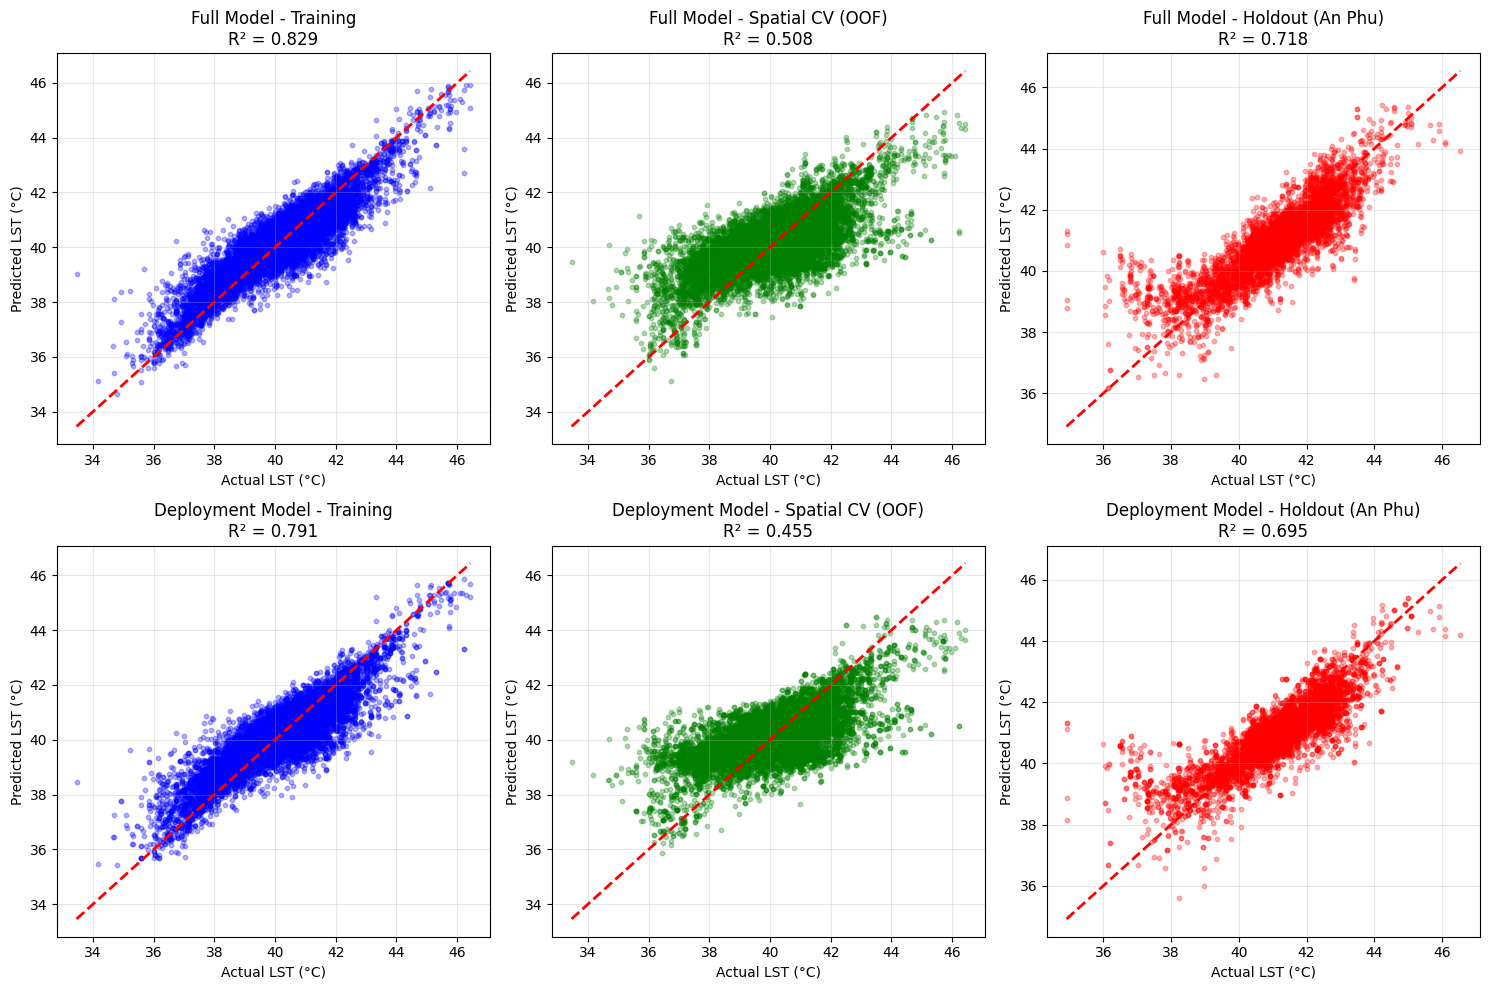

In [ ]:
# Actual vs Predicted (Training, CV, Holdout).
fig, axes = plt.subplots(2, 3, figsize = (15, 10))

# Full model, Training.
axes[0, 0].scatter(y_cv, y_pred_train_full, alpha = 0.3, s = 10, c = "blue")
axes[0, 0].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[0, 0].set_xlabel("Actual LST (°C)")
axes[0, 0].set_ylabel("Predicted LST (°C)")
axes[0, 0].set_title(f"Full Model - Training\nR² = {train_r2_full:.3f}")
axes[0, 0].grid(alpha = 0.3)

# Full model, Spatial CV (out-of-fold).
valid_oof = ~np.isnan(cv_results_full["oof_predictions"])
axes[0, 1].scatter(
    cv_results_full["oof_actuals"][valid_oof],
    cv_results_full["oof_predictions"][valid_oof],
    alpha = 0.3, s = 10, c = "green"
)
axes[0, 1].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[0, 1].set_xlabel("Actual LST (°C)")
axes[0, 1].set_ylabel("Predicted LST (°C)")
axes[0, 1].set_title(f"Full Model - Spatial CV (OOF)\nR² = {cv_results_full['oof_r2']:.3f}")
axes[0, 1].grid(alpha = 0.3)

# Full model, Holdout.
axes[0, 2].scatter(y_holdout, y_pred_holdout_full, alpha = 0.3, s = 10, c = "red")
axes[0, 2].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], "r--", lw = 2)
axes[0, 2].set_xlabel("Actual LST (°C)")
axes[0, 2].set_ylabel("Predicted LST (°C)")
axes[0, 2].set_title(f"Full Model - Holdout ({HOLDOUT_WARD})\nR² = {holdout_r2_full:.3f}")
axes[0, 2].grid(alpha = 0.3)

# Deployment model, Training.
axes[1, 0].scatter(y_cv, y_pred_train_deploy, alpha = 0.3, s = 10, c = "blue")
axes[1, 0].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[1, 0].set_xlabel("Actual LST (°C)")
axes[1, 0].set_ylabel("Predicted LST (°C)")
axes[1, 0].set_title(f"Deployment Model - Training\nR² = {train_r2_deploy:.3f}")
axes[1, 0].grid(alpha = 0.3)

# Deployment model, Spatial CV (out-of-fold).
valid_oof_deploy = ~np.isnan(cv_results_deploy["oof_predictions"])
axes[1, 1].scatter(
    cv_results_deploy["oof_actuals"][valid_oof_deploy],
    cv_results_deploy["oof_predictions"][valid_oof_deploy],
    alpha = 0.3, s = 10, c = "green"
)
axes[1, 1].plot([y_cv.min(), y_cv.max()], [y_cv.min(), y_cv.max()], "r--", lw = 2)
axes[1, 1].set_xlabel("Actual LST (°C)")
axes[1, 1].set_ylabel("Predicted LST (°C)")
axes[1, 1].set_title(f"Deployment Model - Spatial CV (OOF)\nR² = {cv_results_deploy['oof_r2']:.3f}")
axes[1, 1].grid(alpha = 0.3)

# Deployment model, Holdout.
axes[1, 2].scatter(y_holdout, y_pred_holdout_deploy, alpha = 0.3, s = 10, c = "red")
axes[1, 2].plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], "r--", lw = 2)
axes[1, 2].set_xlabel("Actual LST (°C)")
axes[1, 2].set_ylabel("Predicted LST (°C)")
axes[1, 2].set_title(f"Deployment Model - Holdout ({HOLDOUT_WARD})\nR² = {holdout_r2_deploy:.3f}")
axes[1, 2].grid(alpha = 0.3)

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "actual_vs_predicted.png", dpi = 150, bbox_inches = "tight")
plt.show()

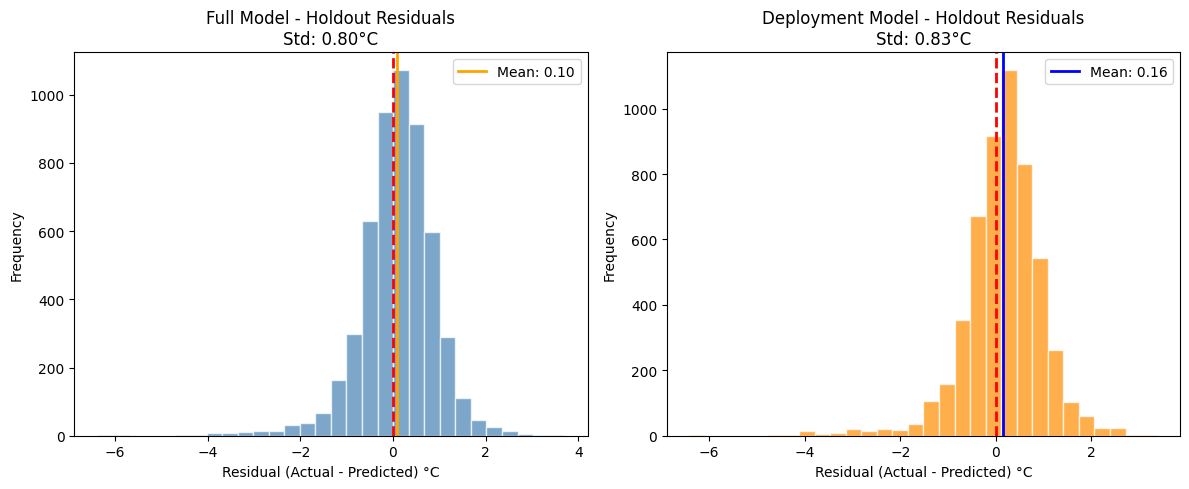

In [ ]:
# Residual distributions.
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Full model residuals.
residuals_full = y_holdout - y_pred_holdout_full
axes[0].hist(residuals_full, bins = 30, color = "steelblue", edgecolor = "white", alpha = 0.7)
axes[0].axvline(0, color = "red", linestyle = "--", lw = 2)
axes[0].axvline(residuals_full.mean(), color = "orange", linestyle = "-", lw = 2, label = f"Mean: {residuals_full.mean():.2f}")
axes[0].set_xlabel("Residual (Actual - Predicted) °C")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Full Model - Holdout Residuals\nStd: {residuals_full.std():.2f}°C")
axes[0].legend()

# Deployment model residuals.
residuals_deploy = y_holdout - y_pred_holdout_deploy
axes[1].hist(residuals_deploy, bins = 30, color = "darkorange", edgecolor = "white", alpha = 0.7)
axes[1].axvline(0, color = "red", linestyle = "--", lw = 2)
axes[1].axvline(residuals_deploy.mean(), color = "blue", linestyle = "-", lw = 2, label = f"Mean: {residuals_deploy.mean():.2f}")
axes[1].set_xlabel("Residual (Actual - Predicted) °C")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Deployment Model - Holdout Residuals\nStd: {residuals_deploy.std():.2f}°C")
axes[1].legend()

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "residual_distributions.png", dpi = 150, bbox_inches = "tight")
plt.show()

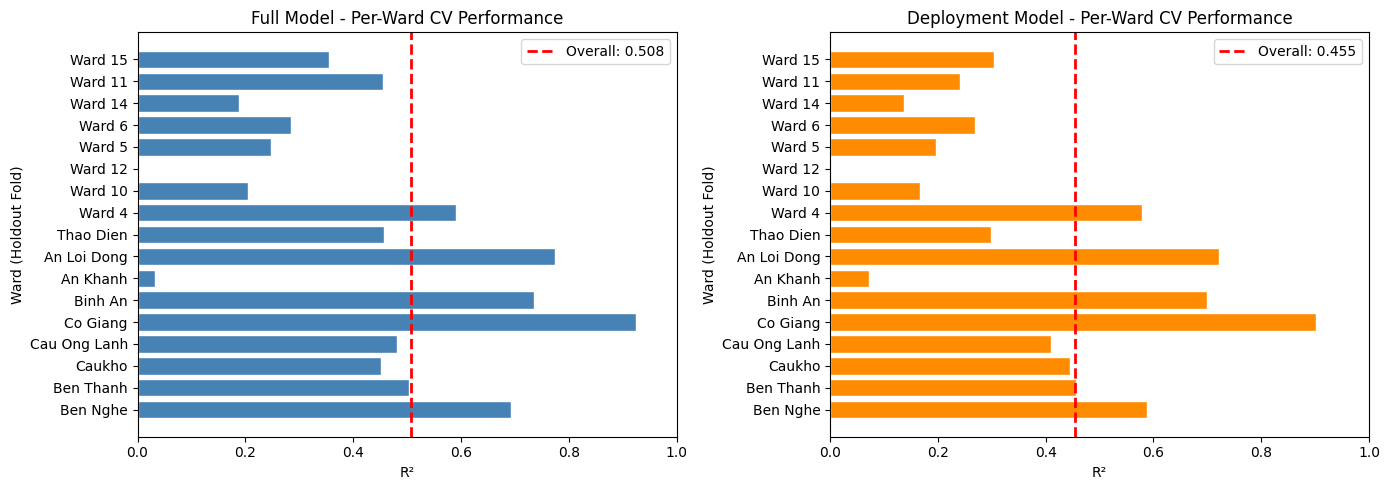

In [ ]:
# Per-ward CV performance.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Full model per-ward R2.
ward_r2_full = pd.DataFrame(cv_results_full["fold_metrics"])
axes[0].barh(ward_r2_full["group"], ward_r2_full["r2"], color = "steelblue", edgecolor = "white")
axes[0].axvline(cv_results_full["oof_r2"], color = "red", linestyle = "--", lw = 2, label = f"Overall: {cv_results_full['oof_r2']:.3f}")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Ward (Holdout Fold)")
axes[0].set_title("Full Model - Per-Ward CV Performance")
axes[0].legend()
axes[0].set_xlim(0, 1)

# Deployment model per-ward R2.
ward_r2_deploy = pd.DataFrame(cv_results_deploy["fold_metrics"])
axes[1].barh(ward_r2_deploy["group"], ward_r2_deploy["r2"], color = "darkorange", edgecolor = "white")
axes[1].axvline(cv_results_deploy["oof_r2"], color = "red", linestyle = "--", lw = 2, label = f"Overall: {cv_results_deploy['oof_r2']:.3f}")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Ward (Holdout Fold)")
axes[1].set_title("Deployment Model - Per-Ward CV Performance")
axes[1].legend()
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "per_ward_cv_performance.png", dpi = 150, bbox_inches = "tight")
plt.show()

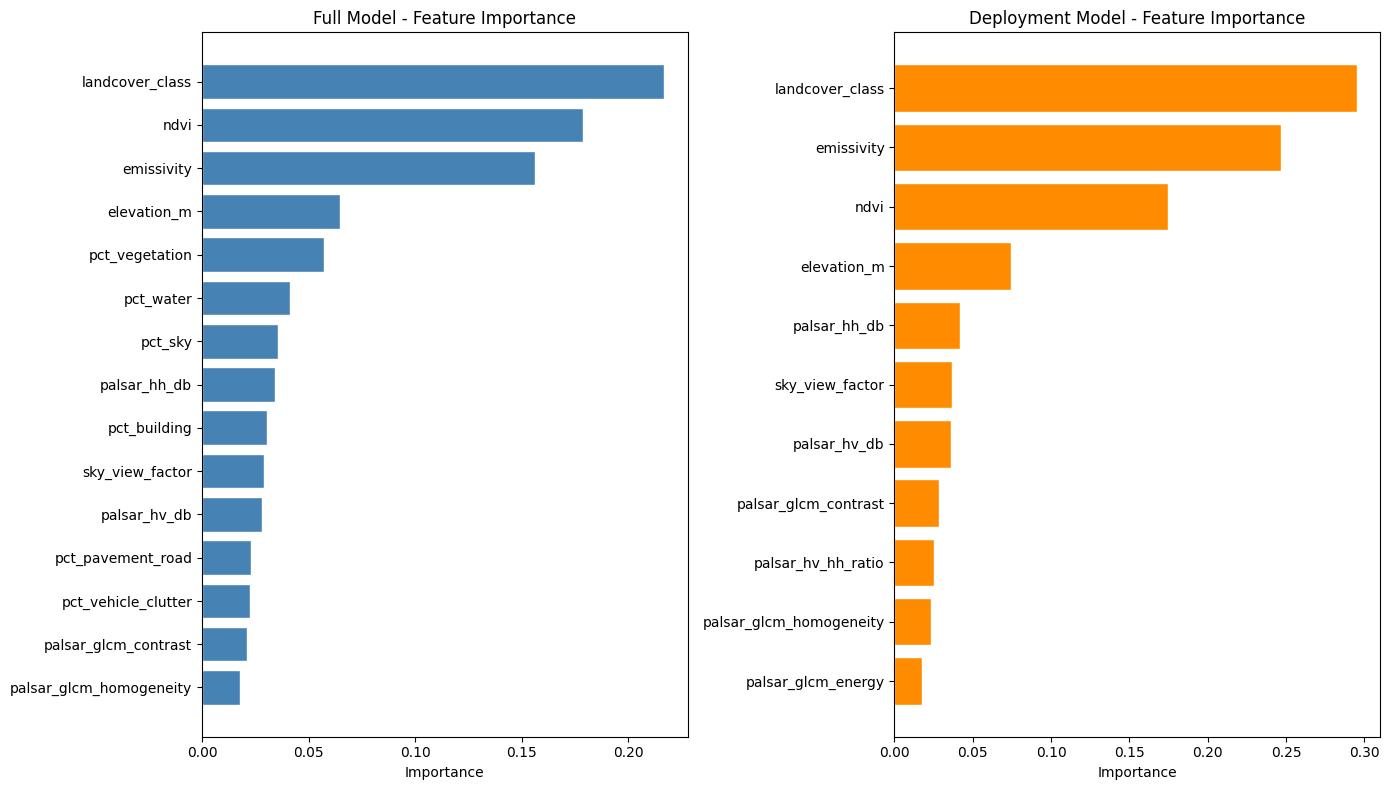

Diagnostic plots saved to: models/diagnostics


In [ ]:
# Feature importance comparison.
fig, axes = plt.subplots(1, 2, figsize = (14, 8))

# Full model.
top_n = min(15, len(importance_full))
axes[0].barh(
    importance_full.head(top_n)["feature"][::-1],
    importance_full.head(top_n)["importance"][::-1],
    color = "steelblue",
    edgecolor = "white"
)
axes[0].set_xlabel("Importance")
axes[0].set_title("Full Model - Feature Importance")

# Deployment model.
axes[1].barh(
    importance_deploy["feature"][::-1],
    importance_deploy["importance"][::-1],
    color = "darkorange",
    edgecolor = "white"
)
axes[1].set_xlabel("Importance")
axes[1].set_title("Deployment Model - Feature Importance")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "feature_importance.png", dpi = 150, bbox_inches = "tight")
plt.show()

print(f"Diagnostic plots saved to: {DIAGNOSTICS_DIR}")

## Save Models

In [ ]:
# Save full model.
full_model_data = {
    "model": model_full,
    "features": ALL_FEATURES,
    "target": TARGET,
    "cv_rmse": cv_results_full["oof_rmse"],
    "cv_r2": cv_results_full["oof_r2"],
    "cv_mae": cv_results_full["oof_mae"],
    "holdout_rmse": holdout_rmse_full,
    "holdout_r2": holdout_r2_full,
    "holdout_mae": holdout_mae_full,
    "holdout_ward": HOLDOUT_WARD,
    "cv_type": "spatial_leave_one_ward_out",
    "feature_importance": importance_full.to_dict()
}

with open(FULL_MODEL, "wb") as f:
    pickle.dump(full_model_data, f)

print(f"Full model saved: {FULL_MODEL}")

# Save deployment model.
deploy_model_data = {
    "model": model_deploy,
    "features": SHARED_FEATURES,
    "target": TARGET,
    "cv_rmse": cv_results_deploy["oof_rmse"],
    "cv_r2": cv_results_deploy["oof_r2"],
    "cv_mae": cv_results_deploy["oof_mae"],
    "holdout_rmse": holdout_rmse_deploy,
    "holdout_r2": holdout_r2_deploy,
    "holdout_mae": holdout_mae_deploy,
    "holdout_ward": HOLDOUT_WARD,
    "cv_type": "spatial_leave_one_ward_out",
    "feature_importance": importance_deploy.to_dict()
}

with open(DEPLOYMENT_MODEL, "wb") as f:
    pickle.dump(deploy_model_data, f)

print(f"Deployment model saved: {DEPLOYMENT_MODEL}")

# Save feature importance.
importance_combined = pd.concat([
    importance_full.assign(model = "full"),
    importance_deploy.assign(model = "deployment")
])

importance_combined.to_csv(FEATURE_IMPORTANCE, index = False)
print(f"Feature importance saved: {FEATURE_IMPORTANCE}")

# Save CV results.
cv_results_combined = pd.concat([
    pd.DataFrame(cv_results_full["fold_metrics"]).assign(model = "full"),
    pd.DataFrame(cv_results_deploy["fold_metrics"]).assign(model = "deployment")
])

cv_results_combined.to_csv(CV_RESULTS, index = False)
print(f"CV results saved: {CV_RESULTS}")

SAVING MODELS
Full model saved: models/xgboost_full_model.pkl
Deployment model saved: models/xgboost_deployment_model.pkl
Feature importance saved: models/feature_importance.csv
CV results saved: models/cv_results.csv


## Final Summary

In [ ]:
print(f"Full Model: Spatial CV R² = {cv_results_full['oof_r2']:.4f}, Holdout R² = {holdout_r2_full:.4f}")
print(f"Deployment Model: Spatial CV R² = {cv_results_deploy['oof_r2']:.4f}, Holdout R² = {holdout_r2_deploy:.4f}")

print("Output Files:")
print(f"{FULL_MODEL}")
print(f"{DEPLOYMENT_MODEL}")
print(f"{FEATURE_IMPORTANCE}")
print(f"{CV_RESULTS}")
print(f"{DIAGNOSTICS_DIR}/")

TRAINING COMPLETE - FINAL SUMMARY

KEY IMPROVEMENTS IN THIS NOTEBOOK:
  1. Spatial cross-validation (leave-one-ward-out) prevents autocorrelation bias.
  2. Holdout ward provides unbiased generalization estimate.
  3. Removed redundant features (gvi, svi, bvi, hardscape_index).
  4. Increased regularization to reduce overfitting.
  5. Early stopping with validation set for final model.

RECOMMENDED METRICS FOR REPORTING:
  Full Model:       Spatial CV R² = 0.5079, Holdout R² = 0.7180
  Deployment Model: Spatial CV R² = 0.4549, Holdout R² = 0.6946

NOTE: These metrics are more conservative than standard K-fold CV
      but provide a more realistic estimate of deployment performance.

Output files:
  models/xgboost_full_model.pkl
  models/xgboost_deployment_model.pkl
  models/feature_importance.csv
  models/cv_results.csv
  models/diagnostics/
